# 神经网络（Neural Network）权重（Weights）可视化

神经网络从宏观上看，每一层只是由矩阵乘法（Matrix Multiplication）组成。矩阵乘法属于线性变换（Linear Transformation）。本可视化展示了每一层的线性变换以及每一层的损失曲面（Loss Landscape）。本 Notebook 建立在 `Neural Network` Notebook 的基础上。请查看上一个 Notebook，了解反向传播（Backpropagation）的推导过程以及神经网络背后的数学原理。

Gavin 的说明：本可视化的目标是展示反向传播以最优的方式更新权重和偏置（Biases）。为了实现可视化，本程序会人为修改权重、使其偏离最优值，从而展示损失（Loss）的增大。因此，本程序运行起来会非常耗时。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# %matplotlib ipympl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from celluloid import Camera
import scienceplots
from IPython.display import Image

torch.manual_seed(0)
np.random.seed(0)
plt.style.use(["science", "no-latex"])

## 训练数据集（Training Dataset）

我们来生成一个非线性数据集，因为神经网络能够拟合这样的函数，而线性模型（例如感知机（Perceptron））无法在该数据集上收敛

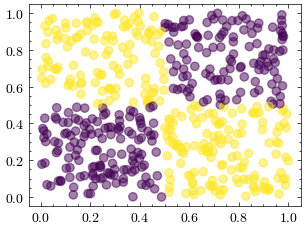

In [2]:
# 生成非线性数据集，即超平面无法分隔这些数据
def generate_XOR():
    N = 500
    X = np.random.rand(N, 2)
    y = (X[:, 0] > 0.5) != (X[:, 1] > 0.5)

    return X, y


X, y = generate_XOR()

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5)

## 绘图函数（Graph Functions）

在训练函数中，我们使用梯度下降优化器（Gradient Descent Optimizer）来更新权重并继续训练。如果我们不使用优化器给出的权重会怎样？这些绘图函数会手动修改神经网络各层权重矩阵中的数值，并运行神经网络，以观察损失如何变化。

还有一些绘图函数用于展示每一层的线性变换。

In [3]:
def create_scatterplots(rows=2, cols=3, width_scale=1, height_scale=1):
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(16 / 9.0 * 4 * width_scale, 4 * height_scale),
        layout="constrained",
    )
    axes = axes.flatten()

    layer_idx = 0
    for i, axis in enumerate(axes):
        if not ((i + 1) % cols == 0):
            axis.set_title(f"Layer {layer_idx}")
            layer_idx += 1

    axes[-1].set_title("Predictions")
    axes[-1 - cols].set_title("Mean Squared Error")

    camera = Camera(fig)
    return axes, camera


def create_3d_plots(rows=2, cols=3, width_scale=1, height_scale=1):
    fig = plt.figure(
        figsize=(16 / 9.0 * 4 * width_scale, 4 * height_scale), layout="constrained"
    )
    axes = []

    layer_idx = 0
    for i in range(rows * cols):
        if not ((i + 1) % cols == 0):
            axis = fig.add_subplot(rows, cols, i + 1, projection="3d")
            axis.set_title(f"Layer {layer_idx + 1}")
            axes.append(axis)
            layer_idx += 1
        else:
            axes.append(fig.add_subplot(rows, cols, i + 1))

    axes[-1].set_title("Predictions")
    axes[-1 - cols].set_title("Mean Squared Error")

    camera = Camera(fig)
    return axes, camera


def plot_layer_loss_landscape(
    axis,
    model,
    target_layer_idx,
    neuron_idx,
    features,
    labels,
    w1_min,
    w1_max,
    w2_min,
    w2_max,
    loss_dims,
    device,
    color="blue",
):
    """Plot how the loss changes when the first two weights in the first neuron change"""
    loss_fn = nn.MSELoss()

    init = model.get_values(target_layer_idx, neuron_idx)
    w1 = init[0].item()
    w2 = init[1].item()

    target_layer_idx = target_layer_idx % len(model.layers)

    w1_range = torch.linspace(w1_min + w1, w1_max + w1, loss_dims).to(device)
    w2_range = torch.linspace(w2_min + w2, w2_max + w2, loss_dims).to(device)
    w1_range, w2_range = torch.meshgrid(w1_range, w2_range, indexing="ij")
    w_range = torch.stack((w1_range.flatten(), w2_range.flatten()), axis=1)

    error_range = np.array([])

    for target_layer_weight in w_range:
        model.override_layer_weight(
            target_layer_idx, neuron_idx, init + target_layer_weight
        )
        error = 0
        for x, y in zip(features, labels):
            output = model(x)
            y = y.unsqueeze(0)
            loss = loss_fn(output, y)
            error += loss.detach().cpu().numpy()
        error /= len(labels)
        error_range = np.append(error_range, error)

        if np.isclose(target_layer_weight[0].item(), w1, atol=0.25) and np.isclose(
            target_layer_weight[1].item(), w2, atol=0.25
        ):
            axis.scatter([w1], [w2], [error], color=color, alpha=0.4)

    axis.plot_surface(
        w1_range.detach().cpu().numpy(),
        w2_range.detach().cpu().numpy(),
        error_range.reshape(loss_dims, loss_dims),
        color=color,
        alpha=0.1,
    )
    model.override_layer_weight(target_layer_idx, neuron_idx, init)


def plot_mse_and_predictions(
    axes, features, idx, visible_mse, mse_idx, errors, predictions, cmap, cols, device
):
    features_cpu = features.detach().cpu().numpy()

    # 绘制 MSE
    mse_ax = axes[-1 - cols]
    mse_ax.plot(
        mse_idx[visible_mse][: idx + 1],
        errors[visible_mse][: idx + 1],
        color="red",
        alpha=0.5,
    )
    mse_ax.plot(
        [1],
        [0],
        color="white",
        alpha=0,
    )

    # 绘制预测结果
    predictions_classes = np.where(predictions > 0.5, 1, 0)

    predictions_ax = axes[-1]
    predictions_ax.scatter(
        features_cpu[:, 0],
        features_cpu[:, 1],
        c=predictions_classes,
        cmap=cmap,
        alpha=0.5,
    )


def plot_transformations_and_predictions(
    axes,
    model,
    idx,
    visible_mse,
    mse_idx,
    errors,
    predictions,
    features,
    labels,
    cmap,
    rows,
    cols,
    device,
):
    plot_mse_and_predictions(
        axes,
        features,
        idx,
        visible_mse,
        mse_idx,
        errors,
        predictions,
        cmap,
        cols,
        device,
    )
    model.visualize(features, labels, axes, cmap, rows, cols)


def plot_loss_landscape_and_predictions(
    axes,
    model,
    idx,
    visible_mse,
    mse_idx,
    errors,
    predictions,
    features,
    labels,
    cmap,
    cols,
    device,
    w1_min=-5,
    w1_max=5,
    w2_min=-5,
    w2_max=5,
    loss_dims=7,
):
    # 这里使用索引为 -1 和 -1-cols 的坐标轴
    plot_mse_and_predictions(
        axes,
        features,
        idx,
        visible_mse,
        mse_idx,
        errors,
        predictions,
        cmap,
        cols,
        device,
    )

    num_layers = len(model.layers)

    target_layer_idx = -1

    for index, axis in enumerate(reversed(axes)):
        # 按相反的顺序，预测图是索引 0，MSE 图是索引 cols
        if index == 0 or index == cols or abs(target_layer_idx) > num_layers:
            continue
        plot_layer_loss_landscape(
            axis,
            model,
            target_layer_idx,
            0,
            features,
            labels,
            w1_min,
            w1_max,
            w2_min,
            w2_max,
            loss_dims,
            device,
            color="blue",
        )
        if target_layer_idx != -1:
            plot_layer_loss_landscape(
                axis,
                model,
                target_layer_idx,
                1,
                features,
                labels,
                w1_min,
                w1_max,
                w2_min,
                w2_max,
                loss_dims,
                device,
                color="red",
            )
        target_layer_idx -= 1

## PyTorch 实现

我们用 PyTorch 定义一个前馈神经网络（Feedforward Neural Network），但为每一层添加自定义函数来手动改变权重值。我们希望用这个函数观察当权重不在最优值时损失如何变化。这用来说明反向传播告诉我们如何最优地更新权重。

In [4]:
class VisualNet(nn.Module):
    def __init__(self):
        super(VisualNet, self).__init__()
        self.layers = nn.ModuleList()

    def visualize(self, X, y, axes, cmap, rows, cols):
        y_cpu = y.detach().cpu().numpy()

        layer_idx = 0
        for i, axis in enumerate(axes):
            if not ((i + 1) % cols == 0):
                X_cpu = X.detach().cpu().numpy()

                # 输入层和隐藏层的输出
                if X.shape[1] != 1:
                    axis.scatter(
                        X_cpu[:, 0], X_cpu[:, 1], c=y_cpu, cmap=cmap, alpha=0.5
                    )
                # 输出层是一维的，所以把第二维设为零
                else:
                    axis.scatter(
                        X_cpu[:, 0],
                        np.zeros(X_cpu[:, 0].shape),
                        c=y_cpu,
                        cmap=cmap,
                        alpha=0.5,
                    )

                if layer_idx < len(self.layers):
                    X = F.tanh(self.layers[layer_idx](X))
                    layer_idx += 1

    def override_layer_weight(self, layer_idx, neuron_idx, new_weights):
        if (abs(layer_idx) > len(self.layers)) or (
            abs(neuron_idx) > len(self.layers[layer_idx].weight)
        ):
            return

        with torch.no_grad():
            self.layers[layer_idx].weight[neuron_idx, :2] = new_weights

    def get_values(self, layer_idx, neuron_idx):
        if (abs(layer_idx) > len(self.layers)) or (
            abs(neuron_idx) > len(self.layers[layer_idx].weight)
        ):
            return torch.zeros(2)

        with torch.no_grad():
            return self.layers[layer_idx].weight.detach().clone()[neuron_idx, :2]


class TorchNet(VisualNet):
    def __init__(self, num_hidden_layers):
        super().__init__()

        # 定义各层
        self.input_layer = nn.Linear(2, 2)
        self.layers.append(self.input_layer)

        for i in range(num_hidden_layers):
            self.layers.append(nn.Linear(2, 2))

        self.output_layer = nn.Linear(2, 1)
        self.layers.append(self.output_layer)

    def forward(self, x):
        # 将上一层的结果传入下一层
        for layer in self.layers[:-1]:
            x = F.tanh(layer(x))

        return self.output_layer(x)

## 训练模型

与之前的 Neural Network Notebook 类似，我们将训练数据传入模型，用优化器更新权重，并更新可视化

In [5]:
def torch_fit(
    model,
    features,
    labels,
    epochs,
    learning_rate,
    transformations_plot_filename,
    loss_landscape_plot_filename,
    device,
    rows=2,
    cols=3,
    width_scale=1,
    height_scale=1,
):
    mse_idx = np.arange(1, epochs + 1)
    errors = np.full(epochs, -1)

    cmap = plt.cm.colors.ListedColormap(["red", "blue"])

    scatterplots, camera1 = create_scatterplots(rows, cols, width_scale, height_scale)
    loss_plots, camera2 = create_3d_plots(rows, cols, width_scale, height_scale)

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.3)

    for idx in range(epochs):
        error = 0
        predictions = np.array([])

        for x, y in zip(features, labels):
            # 前向传播（Forward Propagation）
            output = model(x)

            output_np = output.detach().cpu().numpy()
            predictions = np.append(predictions, output_np)

            # 存储误差
            # tensor(0.) -> tensor([0.])，以匹配输出变量的形状
            y = y.unsqueeze(0)
            loss = loss_fn(output, y)

            error += loss.detach().cpu().numpy()

            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if (
            idx < 5
            or (idx <= 50 and idx % 5 == 0)
            or (idx <= 1000 and idx % 50 == 0)
            or idx % 250 == 0
        ):
            print(f"epoch: {idx}, MSE: {error}")

            # 绘制 MSE
            errors[idx] = error
            visible_mse = errors != -1

            plot_transformations_and_predictions(
                scatterplots,
                model,
                idx,
                visible_mse,
                mse_idx,
                errors,
                predictions,
                features,
                labels,
                cmap,
                rows,
                cols,
                device,
            )

            plot_loss_landscape_and_predictions(
                loss_plots,
                model,
                idx,
                visible_mse,
                mse_idx,
                errors,
                predictions,
                features,
                labels,
                cmap,
                cols,
                device,
            )

            camera1.snap()
            camera2.snap()

    animation1 = camera1.animate()
    animation1.save(transformations_plot_filename, writer="pillow")
    animation2 = camera2.animate()
    animation2.save(loss_landscape_plot_filename, writer="pillow")

    plt.show()

## 可视化变换与权重更新

调用我们的训练函数来生成可视化。

epoch: 0, MSE: 137.9026336669922
epoch: 1, MSE: 127.58297729492188
epoch: 2, MSE: 127.3271713256836
epoch: 3, MSE: 127.13655853271484
epoch: 4, MSE: 126.98948669433594
epoch: 5, MSE: 126.87287139892578
epoch: 10, MSE: 126.53106689453125
epoch: 15, MSE: 126.36543273925781
epoch: 20, MSE: 126.266357421875
epoch: 25, MSE: 126.19721984863281
epoch: 30, MSE: 126.14079284667969
epoch: 35, MSE: 126.08564758300781
epoch: 40, MSE: 126.01984405517578
epoch: 45, MSE: 125.92532348632812
epoch: 50, MSE: 125.76524353027344
epoch: 100, MSE: 95.95246124267578
epoch: 150, MSE: 56.10152053833008
epoch: 200, MSE: 54.98665237426758
epoch: 250, MSE: 38.98552703857422
epoch: 300, MSE: 20.435640335083008
epoch: 350, MSE: 13.933258056640625
epoch: 400, MSE: 11.308575630187988
epoch: 450, MSE: 9.152091979980469
epoch: 500, MSE: 7.561526298522949
epoch: 550, MSE: 6.4366888999938965
epoch: 600, MSE: 5.587584018707275


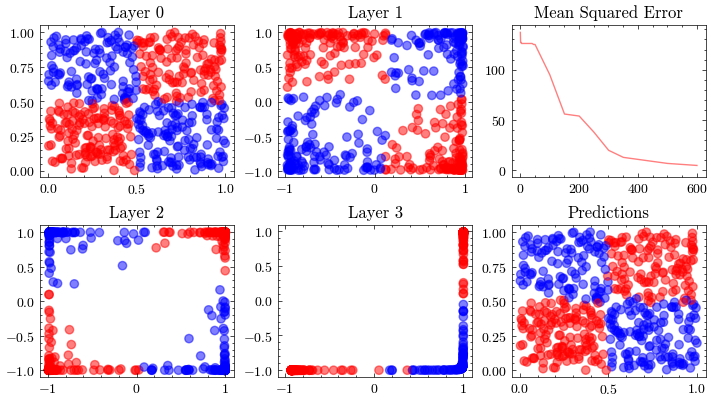

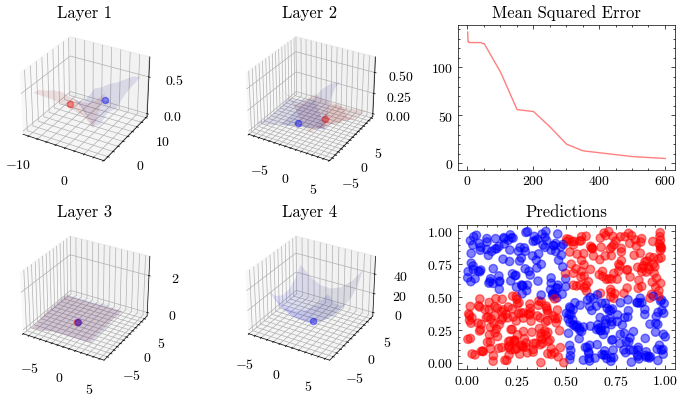

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch_model = TorchNet(num_hidden_layers=2).to(device)

rows = 2
cols = 3

# PyTorch 的输入和输出必须是张量（Tensor）
X_tensor = torch.tensor(X, device=device, dtype=torch.float32).squeeze(-1)
y_tensor = torch.tensor(y, device=device, dtype=torch.float32).squeeze(-1)

epochs = 601
learning_rate = 0.005

transformations_plot_filename = "neural_network_weights.gif"
loss_landscape_plot_filename = "neural_network_weights_loss_landscape.gif"
torch_fit(
    torch_model,
    X_tensor,
    y_tensor,
    epochs,
    learning_rate,
    transformations_plot_filename,
    loss_landscape_plot_filename,
    device,
    rows=rows,
    cols=cols,
)

这个可视化展示了神经网络中每一层的内部线性变换。我们将展示每一层如何把输入变换为输出。在第 3 层，数据变得线性可分（Linearly Separable）。通过这些变换，网络能够将输入划分到这两个类别中。

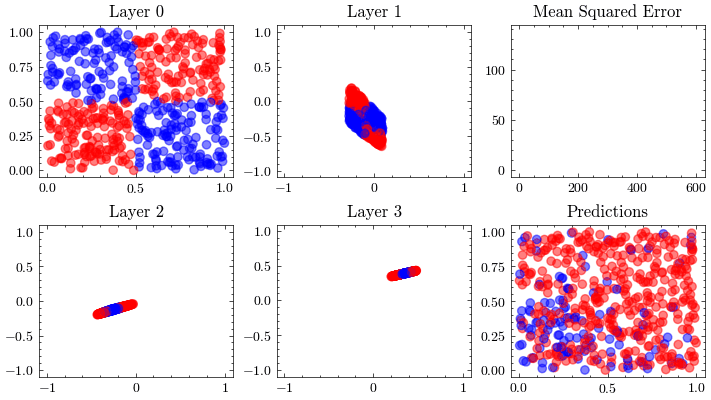

In [7]:
Image(filename=transformations_plot_filename)

这个可视化表明所有权重会一同更新，使最后一层的损失函数达到最小值。观察第 4 层中的 3D 图如何处于最小值处。

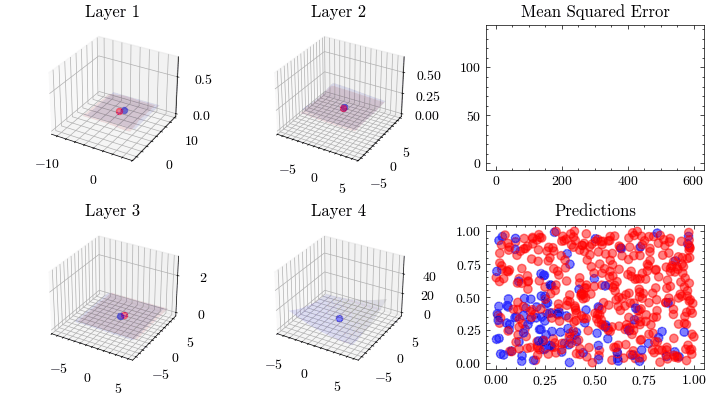

In [8]:
Image(filename=loss_landscape_plot_filename)

## 梯度消失（Vanishing Gradients）

一个合理的假设是，增加神经网络的层数能让它识别出更多模式。然而，扩展并没有这么简单。在架构选择不当时，网络可能无法继续扩展。接下来的可视化将层数增加到 12 层，并展示权重无法更新的情况。这就是所谓的梯度消失，因为传递到网络较早层的更新量接近于零，导致权重无法更新。ResNet 论文引入了残差连接（Residual Connections），有助于解决这个问题。

### 12 层神经网络

我们重新运行代码，但这次使用一个更大的网络

epoch: 0, MSE: 140.93698120117188
epoch: 1, MSE: 127.2381362915039
epoch: 2, MSE: 127.21744537353516
epoch: 3, MSE: 127.19805145263672
epoch: 4, MSE: 127.17977905273438
epoch: 5, MSE: 127.1625747680664
epoch: 10, MSE: 127.08917236328125
epoch: 15, MSE: 127.03060150146484
epoch: 20, MSE: 126.98188018798828
epoch: 25, MSE: 126.94023895263672
epoch: 30, MSE: 126.90355682373047
epoch: 35, MSE: 126.87098693847656
epoch: 40, MSE: 126.84139251708984
epoch: 45, MSE: 126.81401062011719
epoch: 50, MSE: 126.78815460205078
epoch: 100, MSE: 126.53387451171875
epoch: 150, MSE: 126.2475814819336
epoch: 200, MSE: 126.10691833496094
epoch: 250, MSE: 126.07827758789062
epoch: 300, MSE: 126.07350158691406
epoch: 350, MSE: 126.07276153564453
epoch: 400, MSE: 126.0726318359375
epoch: 450, MSE: 126.072509765625
epoch: 500, MSE: 126.07250213623047
epoch: 550, MSE: 126.07252502441406
epoch: 600, MSE: 126.07251739501953
epoch: 650, MSE: 126.07252502441406
epoch: 700, MSE: 126.07251739501953
epoch: 750, MSE: 12

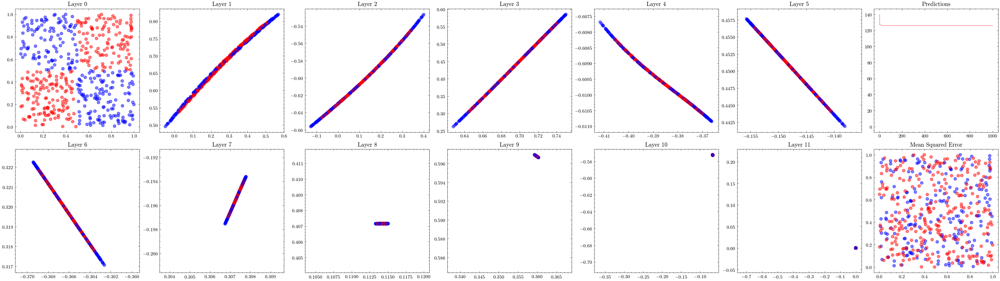

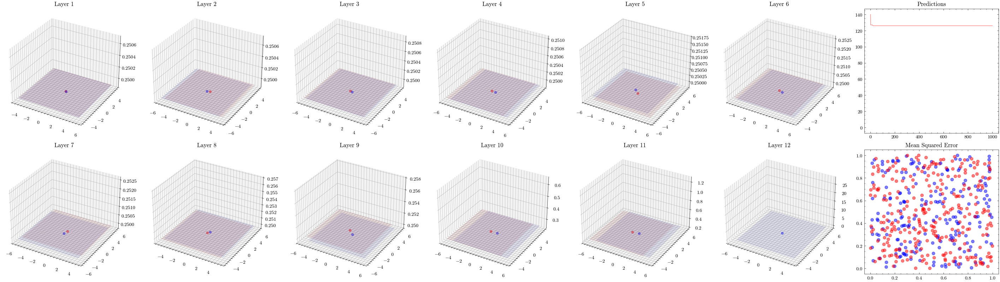

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch_model = TorchNet(num_hidden_layers=10).to(device)

rows = 2
cols = 7

X_tensor = torch.tensor(X, device=device, dtype=torch.float32).squeeze(-1)
y_tensor = torch.tensor(y, device=device, dtype=torch.float32).squeeze(-1)

epochs = 1001
learning_rate = 0.005

width_scale = 4
height_scale = 2

transformations_plot_filename = "vanishing_gradients/layers_12.gif"
loss_landscape_plot_filename = "vanishing_gradients/layers_12_loss_landscape.gif"
torch_fit(
    torch_model,
    X_tensor,
    y_tensor,
    epochs,
    learning_rate,
    transformations_plot_filename,
    loss_landscape_plot_filename,
    device,
    rows=rows,
    cols=cols,
    width_scale=width_scale,
    height_scale=height_scale,
)

在下面的可视化中，我们可以看到由于梯度消失，较早的层完全没有更新。

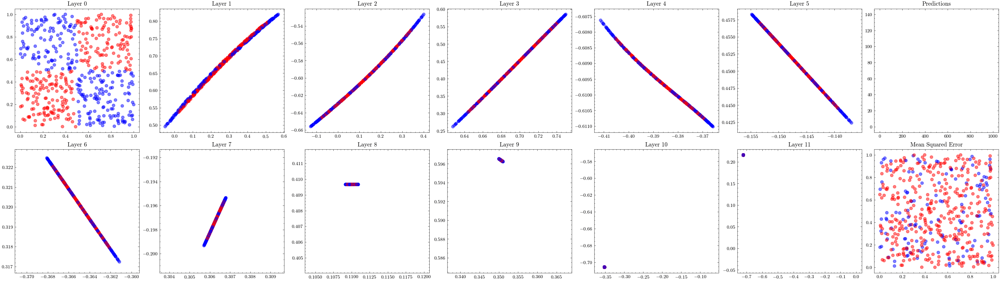

In [10]:
Image(filename=transformations_plot_filename)

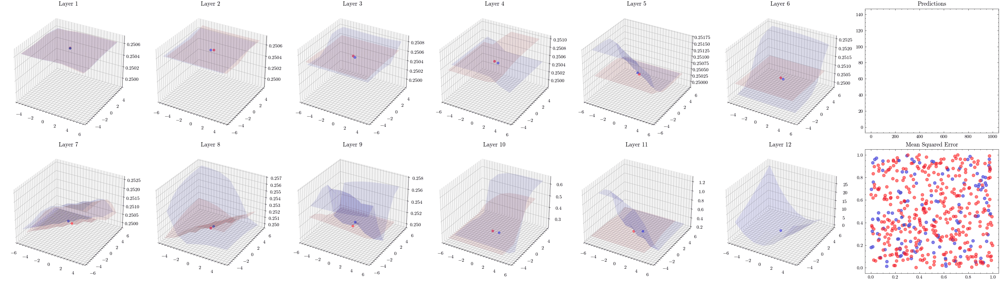

In [11]:
Image(filename=loss_landscape_plot_filename)